In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append('../..')

In [3]:
import pylab as plt
import numpy as np

from stable_baselines3 import PPO

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import run_method
from vimms_gym.common import METHOD_TOPN, METHOD_PPO
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [15]:
eval_dir = 'visualisation'

In [16]:
for chems in chem_list:
    print(len(chems))

2605


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [19]:
all_results = {}

In [20]:
env_name = 'DDAEnv'

### Run PPO

In [21]:
method = METHOD_PPO

In [22]:
model_name = 'PPO'

In [23]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [24]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [25]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (2605 chemicals)
steps	 500 	total rewards	 126.05454501055345
steps	 1000 	total rewards	 304.6379230536947
steps	 1500 	total rewards	 485.0688014327754
steps	 2000 	total rewards	 692.4191977863782
steps	 2500 	total rewards	 881.4475073745193
steps	 3000 	total rewards	 1093.930841202759
Finished after 3307 timesteps with total reward 1231.2162258520557
{'coverage_prop': '0.976', 'intensity_prop': '0.543', 'ms1/ms2 ratio': '0.265', 'efficiency': '0.972', 'TP': '1167', 'FP': '1130', 'FN': '308', 'precision': '0.508', 'recall': '0.791', 'f1': '0.619'}


In [26]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [27]:
method = METHOD_TOPN

In [28]:
topN_N = 20
topN_rt_tol = 30

In [29]:
copy_params = dict(params)        
copy_params['env']['rt_tol'] = topN_rt_tol

In [30]:
model = None

In [31]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (2605 chemicals)
steps	 500 	total rewards	 39.37256040869548
steps	 1000 	total rewards	 108.19211930991464
steps	 1500 	total rewards	 171.6179665074023
steps	 2000 	total rewards	 239.09292287993338
steps	 2500 	total rewards	 308.8877357708552
steps	 3000 	total rewards	 377.6575387029691
steps	 3500 	total rewards	 440.900943819537
Finished after 3641 timesteps with total reward 458.5464268964072
{'coverage_prop': '0.766', 'intensity_prop': '0.561', 'ms1/ms2 ratio': '0.109', 'efficiency': '0.608', 'TP': '1433', 'FP': '373', 'FN': '799', 'precision': '0.793', 'recall': '0.642', 'f1': '0.710'}


In [32]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [47]:
limit = 2000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

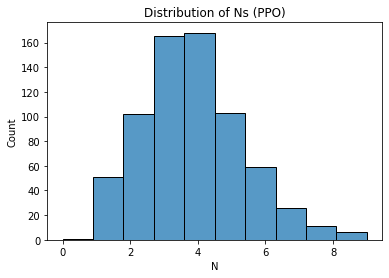

In [34]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

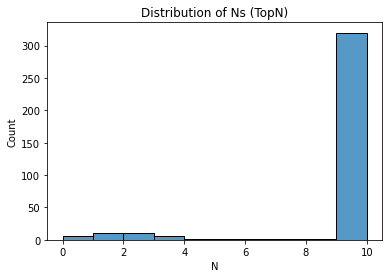

In [35]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

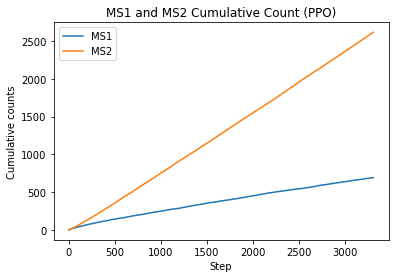

In [36]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

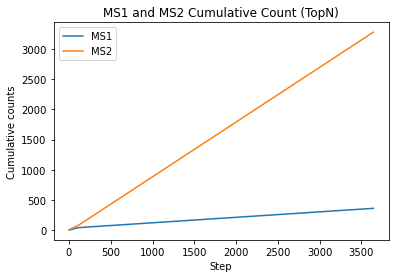

In [37]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

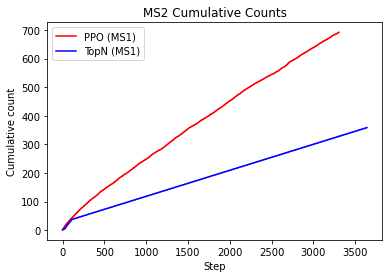

In [38]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

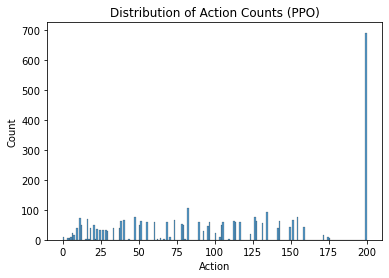

In [39]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

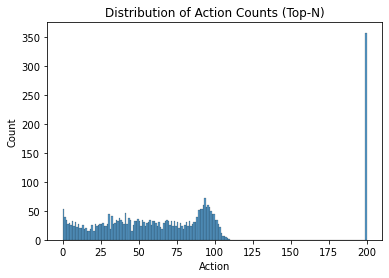

In [40]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

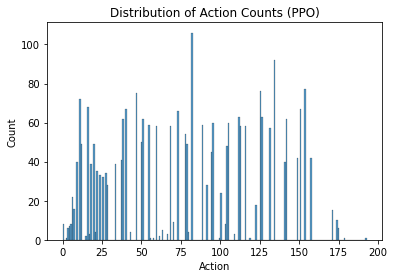

In [41]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

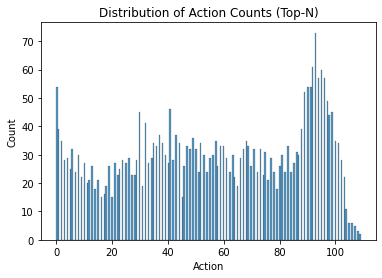

In [42]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

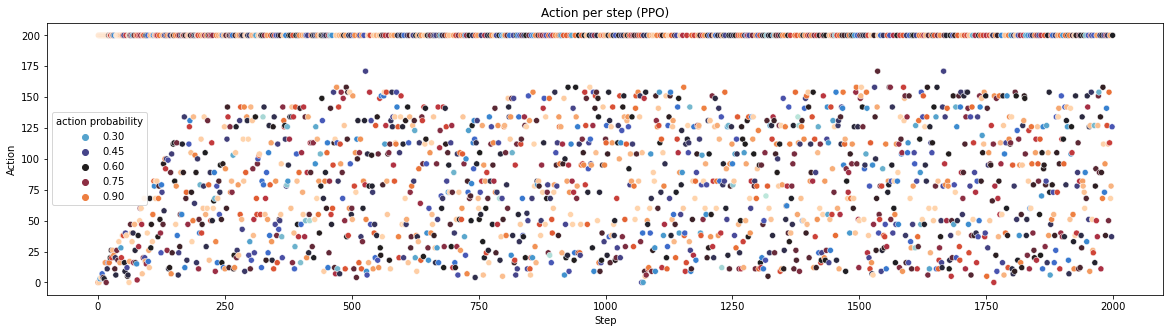

In [48]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

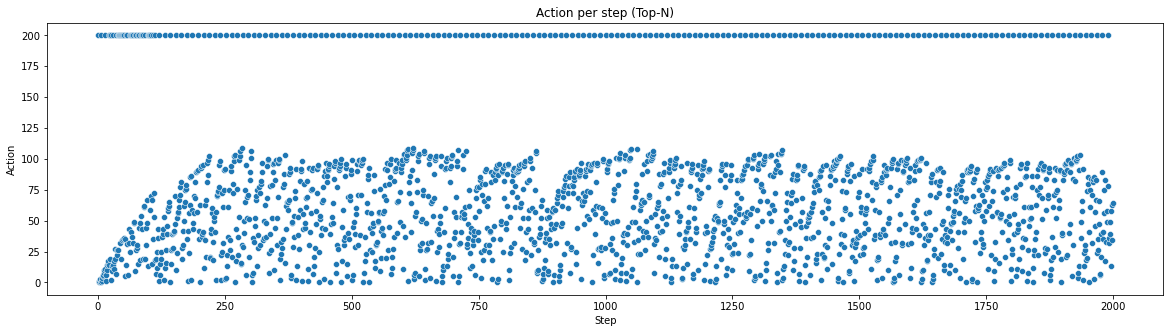

In [49]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

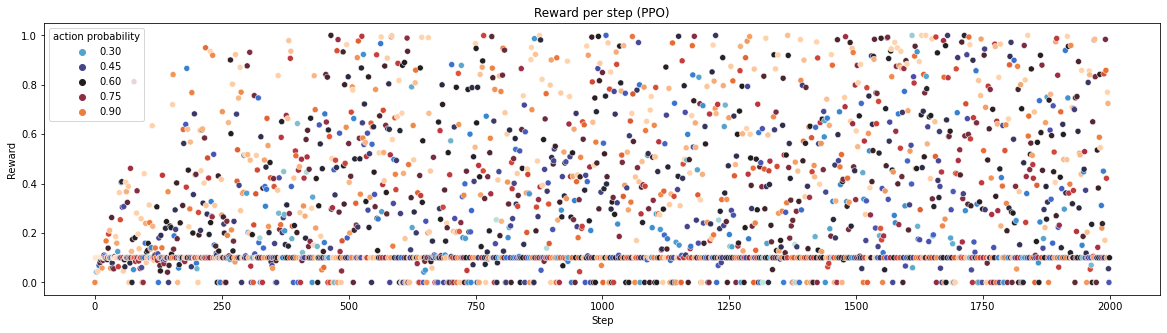

In [50]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

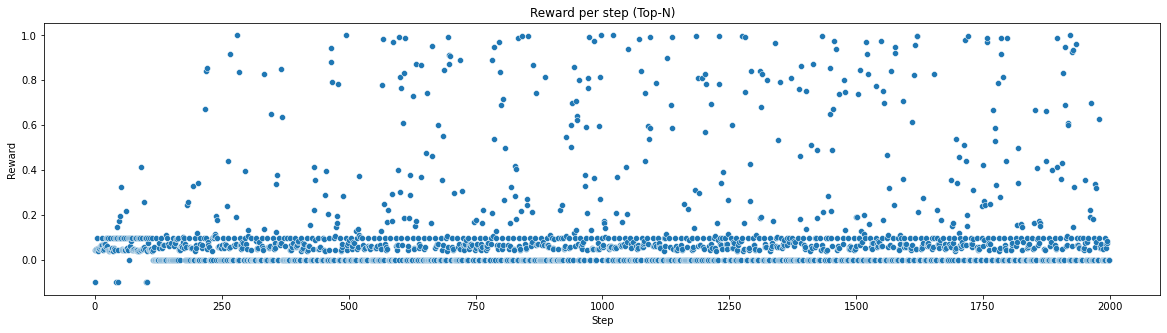

In [51]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')